In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display # Grafikler için
import matplotlib.pyplot as plt

In [2]:
# KLASİK ARAMA (Karşılaştırma İçin)
print("--- KLASİK ARAMA ---")
myList = [5, 4, 6, 9, 1, 2, 3, 7, 8, 0]
target_number = 8

def oracle_classic(number):
    return number == target_number

for index, number in enumerate(myList):
    if oracle_classic(number):
        print(f"Aranan sayı ({target_number}) bulundu!")
        print(f"İndeks: {index}")
        print(f"Deneme sayısı: {index + 1}")
        break

--- KLASİK ARAMA ---
Aranan sayı (8) bulundu!
İndeks: 8
Deneme sayısı: 9



--- KUANTUM ARAMA (Grover) ---
1. Oracle Devresi:


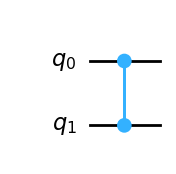

In [3]:
# KUANTUM ARAMA (Grover Algoritması)
print("\n--- KUANTUM ARAMA (Grover) ---")
# Hedef: |11> Durumunu (Decimal 3) Bulmak
# 2 Kübitlik sistemde 4 olasılık var: 00, 01, 10, 11.

#ORACLE DEVRESİ (Aranan elemanı işaretler)
# Hedefimiz |11> olduğu için CZ kapısı kullanıyoruz.
# CZ kapısı sadece |11> durumunun fazını ters çevirir (- işaretler).
oracle_circuit = QuantumCircuit(2, name="Oracle (|11>)")
oracle_circuit.cz(0, 1)
oracle_circuit.to_gate()

print("1. Oracle Devresi:")
display(oracle_circuit.draw(output='mpl'))

2. Diffuser (Reflection) Devresi:


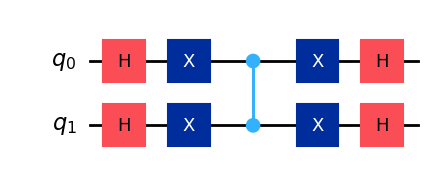

In [4]:
# DIFFUSER (REFLECTION) DEVRESİ (Genliği Büyütür)
# Bu devre "Ortalamaya göre yansıtma" yapar.
# Standart Yapı: H -> X -> CZ -> X -> H
reflection_circuit = QuantumCircuit(2, name="Diffuser")
reflection_circuit.h([0, 1]) # Süperpozisyondan çık
reflection_circuit.x([0, 1]) # 0'ları 1 yap
reflection_circuit.cz(0, 1)  # İşaretle
reflection_circuit.x([0, 1]) # Geri çevir
reflection_circuit.h([0, 1]) # Tekrar süperpozisyon
reflection_circuit.to_gate()

print("2. Diffuser (Reflection) Devresi:")
display(reflection_circuit.draw(output='mpl'))

3. Ana Devre (Grover):


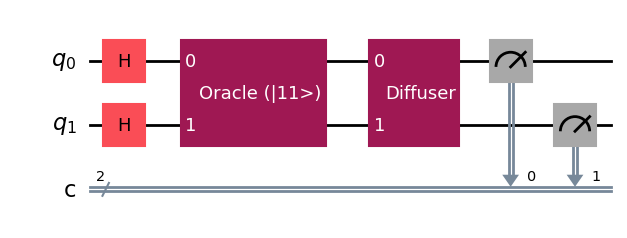

In [5]:
# ANA DEVRE (Birleştirme)
main_circuit = QuantumCircuit(2, 2)

# Başlangıç Süperpozisyonu (Tüm olasılıkları yarat)
main_circuit.h([0, 1])

# Grover İterasyonu (Oracle + Diffuser)
# 2 Kübit için 1 tekrar yeterlidir (π/4 * √N ≈ 1)
main_circuit.append(oracle_circuit, [0, 1])
main_circuit.append(reflection_circuit, [0, 1])

main_circuit.measure([0, 1], [0, 1])

print("3. Ana Devre (Grover):")
display(main_circuit.draw(output='mpl'))


Kuantum Sonuçları: {'11': 1024}


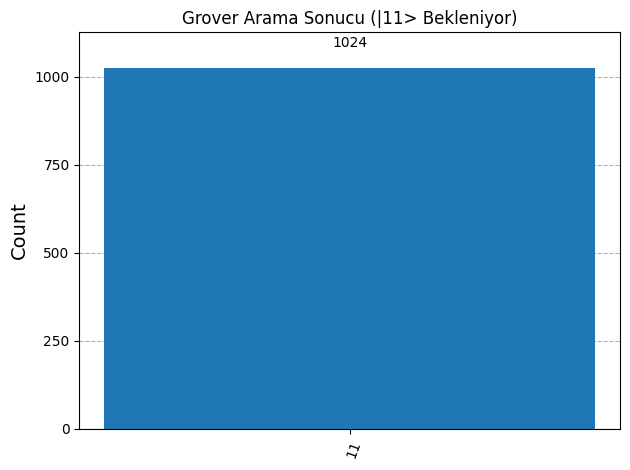

In [6]:
simulator = AerSimulator()
t_circ = transpile(main_circuit, simulator)

result = simulator.run(t_circ, shots=1024).result()
counts = result.get_counts()

print("\nKuantum Sonuçları:", counts)
display(plot_histogram(counts, title="Grover Arama Sonucu (|11> Bekleniyor)"))